# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Raihan Putra Syarif Hidayatulloh
- **Email:** raiham.rp@gmail.com
- **ID Dicoding:** CDCC156D6Y2762

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penyewaan sepeda berdasarkan jam dalam sehari serta perbedaan antara hari kerja dan hari libur?
- Seberapa besar pengaruh faktor cuaca dan lingkungan terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [ ]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

**Insight:**
- dataset terdiri dari 2 file yaitu day.scv yang memiliki 731 data harian dan pada file hour.csv memiliki 17.379 data perjam. dari data yang ada dapat di analisis dengan baik secara makro atau mikro karena memiliki data harian dan perjam. kedua data ini memiliki sturktur kolom yang hampir sama hanya berbeda ada tambahan kolom hr pada data perjam.
- dataset ini memiliki berbagai variabel penting seperti waktu, kondisi hari, cuaca, dan tipe pengguna, dengan cnt sebagai target utama (jumlah penyewaan). pada tipe data secara keseluruhan sudah sesuai hanya saja pada kolom dteday masih bertipe object sehingga perlu diubah menjadi datetime agar mendukung analisis waktu.

### Assessing Data

In [ ]:
day_df.info()
hour_df.info()

# cek missing
day_df.isnull().sum()
hour_df.isnull().sum()

# cek duplicated
day_df.duplicated().sum()
hour_df.duplicated().sum()

day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- pada kualitas data yang didapat ini sudah baik karena dataset tidak memilki missing value atau duplikat sehingga data ini sudah masuk ke dalam kategori  baik dan bersih. tetapi pada kolom dteday masih bertipe object sehingga perlu diubah menjadi datetime agar mendukung analisis waktu. selain itu terdapat beberapa kolom seperti season, weathersit, weekday dan working day masih berupa angka sehingga perlu adanya mapping agar lebih mudah dipahami.
- berdasarkan statistik deskripstif yang di dapat tidak di temukan outlier yang ekstrem dan masih dalam rentang yang wajar yaitu 22-8714. selain itu mayorias pengguna sepeda ini di dominasi oleh pengguna yang sudah terdaftar atau yang rutin dibandingkan dengan pengguna kasual.

### Cleaning Data

In [ ]:
day_clean = day_df.copy()
hour_clean = hour_df.copy()

# covert tipe data dteday
day_clean['dteday'] = pd.to_datetime(day_clean['dteday'])
hour_clean['dteday'] = pd.to_datetime(hour_clean['dteday'])

# rename
day_clean.rename(columns={'cnt': 'total_rentals'}, inplace=True)
hour_clean.rename(columns={'cnt': 'total_rentals'}, inplace=True)

# mapping kategori

# season
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

# weather
weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

# apply mapping
day_clean['season_label'] = day_clean['season'].map(season_map)
hour_clean['season_label'] = hour_clean['season'].map(season_map)

day_clean['weather_label'] = day_clean['weathersit'].map(weather_map)
hour_clean['weather_label'] = hour_clean['weathersit'].map(weather_map)

# cek hasil
day_clean.info()
hour_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   instant        731 non-null    int64         
 1   dteday         731 non-null    datetime64[ns]
 2   season         731 non-null    int64         
 3   yr             731 non-null    int64         
 4   mnth           731 non-null    int64         
 5   holiday        731 non-null    int64         
 6   weekday        731 non-null    int64         
 7   workingday     731 non-null    int64         
 8   weathersit     731 non-null    int64         
 9   temp           731 non-null    float64       
 10  atemp          731 non-null    float64       
 11  hum            731 non-null    float64       
 12  windspeed      731 non-null    float64       
 13  casual         731 non-null    int64         
 14  registered     731 non-null    int64         
 15  total_rentals  731 non-

**Insight:**
- perbaikan struktur dan data telah dilakukan untuk hasil yang di dapat yaitu kolom dteday telah di convert menjadi datetime, pada kolom cnt diubah menjadi total_rentals supaya menjadi lebih jelas dan ada penambahan kolom season_label dan weather_label untuk membuat data lebih mudah dipahami dan untuk visualisasi data.
- pada proses cleaning data ini tidak terdapat missing value atau duplikat dan tipe data sudah sesuai dengan kebutuhan analisis sehingga struktur data lebih informatif dan siap untuk ke tahap analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore Pola Waktu, Hari, Cuaca, dan Musim terhadap Penyewaan Sepeda

In [ ]:
# pola rata-rata per jam
hourly_usage = hour_clean.groupby('hr')['total_rentals'].mean().reset_index()

# pola berdasarkan working day
workingday_usage = day_clean.groupby('workingday')['total_rentals'].mean().reset_index()

# pengaruh cuaca
weather_usage = day_clean.groupby('weather_label')['total_rentals'].mean().reset_index()

# korelasi antar variabel
correlation = day_clean[['temp','hum','windspeed','total_rentals']].corr()

season_usage = day_clean.groupby('season_label')['total_rentals'].mean().reset_index()
monthly_usage = day_clean.groupby('mnth')['total_rentals'].mean().reset_index()

**Insight:**
- pola penyewaan dipengaruhi oleh waktu dan jenis hari karena dari agregasi yang telah dilakukan menunjukkan jumlah penyewaan sepeda bervariasi berdasarkan jam perhari dan hari kerja atau hari libur.
- faktor cuaca dan lingkungan mempengaruhi penyewaan sepeda karena berdasarkan pengelompokan dan analisis korelasi kondisi cuaca dan elemen lingkungan seperti suhu, kelembapan, dan kecepatan angin dikaitkan dengan jumlah penyewaan sepeda, menunjukkan bahwa kenyamanan lingkungan merupakan faktor penting dalam tingkat penggunaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

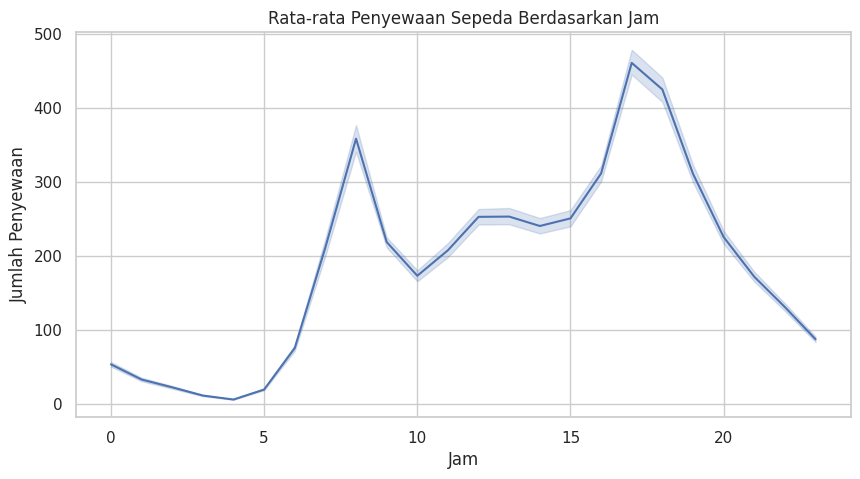

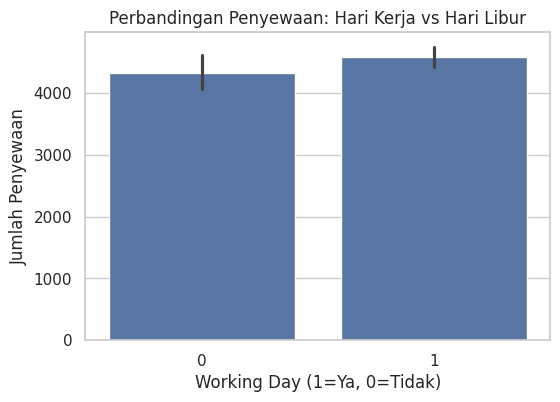

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=hour_clean, x='hr', y='total_rentals', estimator='mean')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=day_clean, x='workingday', y='total_rentals')
plt.title('Perbandingan Penyewaan: Hari Kerja vs Hari Libur')
plt.xlabel('Working Day (1=Ya, 0=Tidak)')
plt.ylabel('Jumlah Penyewaan')
plt.show()

### Pertanyaan 2:

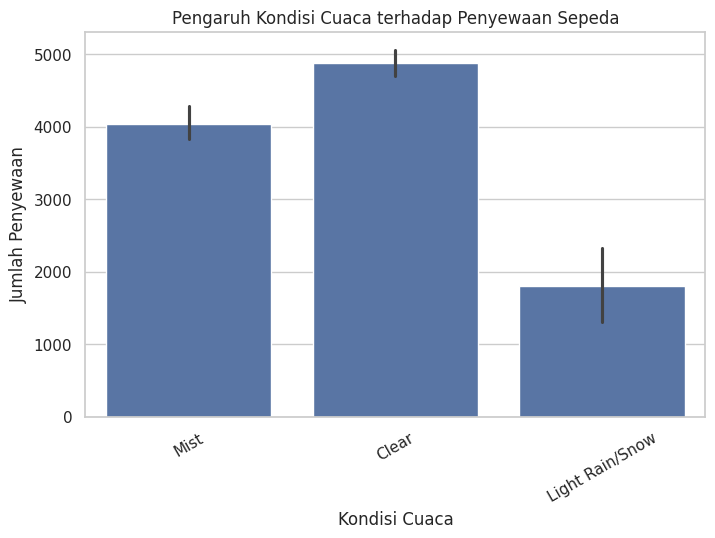

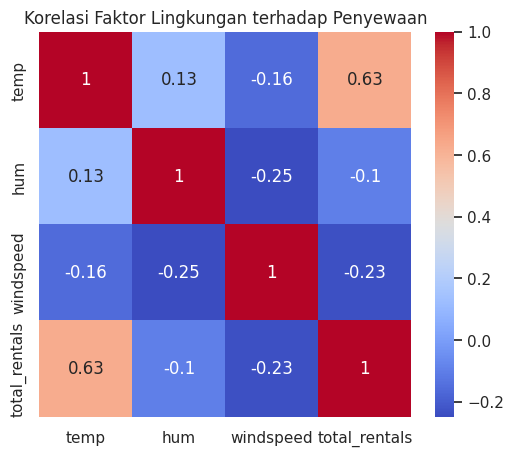

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_clean, x='weather_label', y='total_rentals')
plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(day_clean[['temp','hum','windspeed','total_rentals']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Korelasi Faktor Lingkungan terhadap Penyewaan')
plt.show()

**Insight:**
- Visualisasi pertanyaan 1: dari hasil visualisasi yang didapat penyewaan sepeda sangat rendah pada waktu dini hari kemudian melonjak tinggi pada pagi hari sekitar pukul jam 07.00-09.00 pagi dan juga mecapai peak hours atau puncak tertinggi penyewaan pada sore hari sekitar pukul 17.00-18.00. selian itu, pada hari kerja tingkat penyewaan lebih tinggi dibandingkan dengan hari libur yang mengidentifikasi pengguna penyewaaan sepeda mayoritas untuk kebutuhan yang rutin seperti bekerja atau sekolah.
- Visualisasi pertanyaan 2: dari hasil visualiasi yang didapat kondisi cuaca sangat mempengaruhi jumlah penyewaan sepeda. pada penyewaan tertinggi itu pada kondisi cuaca cera(clear), yang kedua yaitu cuaca berkabut(mist) dan menurun cukup signifikan pada cuaca buruk yaitu pada saat hujan atau salju(light rain/snow). hal ini menunjukkan semakin buruk cuaca semakin menurun penyewaan sepeda. selain itu berdasarkan heatmap korelasi temperatur memiliki faktor paling kuat dibanding yang lainnya karena temperatur memiliki korelasi yang positif tehadap jumlah penyewaan sedangkan kelembapan atau kecepatan angin memiliki korelasi yang lemah. ini menunjukkan cuaca yang hangat meningkatkan penyewaan sepeda dan untuk kondisi lembab dan berangin sedikit menurunkan terhadap penyewaan sepeda.

## Analisis Lanjutan (Opsional)

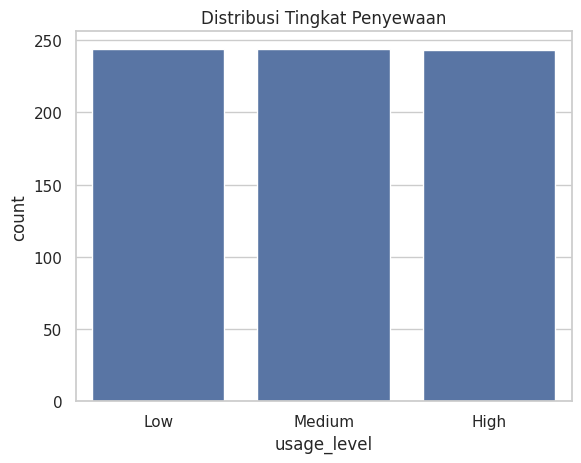

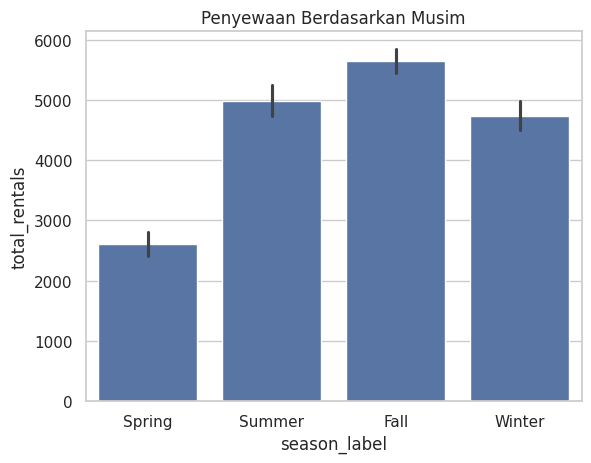

In [ ]:
day_clean['usage_level'] = pd.qcut(day_clean['total_rentals'],
                                  q=3,
                                  labels=['Low', 'Medium', 'High'])

sns.countplot(x='usage_level', data=day_clean)
plt.title('Distribusi Tingkat Penyewaan')
plt.show()

sns.barplot(x='season_label', y='total_rentals', data=day_clean)
plt.title('Penyewaan Berdasarkan Musim')
plt.show()

## Conclusion

- Conclution pertanyaan 1: pada pola penyewaan sepeda sangat dipengaruhi oleh waktu, terjadi peningkatan yang signifikan pada jam sibuk pagi hari pada pukul 07.00 - 09.00 dan sore hari pada 17.00 - 18.00 ini menunjukkan penggunaan untuk aktivitas commuting. selain itu juga ini diperkuat dengan jumlah penyewaan pada hari kerja lebih tinggi dibandingkan dengan hari libur dan ini menandakan pengguna penyewaan sepeda mayoritas untuk kebutuhan yang rutin seperti untuk bekerja atau bersekolah bukan untuk rekreasi.
- Conclution pertanyaan 2: pengaruh cuaca dan faktor lingkungan terhadap tingkat penyewaan ini membuktikan berpengaruh karena dari hasil yang dapat dilihat cuaca cerah dan temperatur yang lebih tinggi meningkatkan penyewaan sepeda sedangkan cuaca yang buruk, faktor kelembapan dan juga angin ini dapat menurunkan tingkat penyewaan sepeda. selain itu juga, faktor musim juga cukup berperan dengan tingkat penyewaan yang lebih tinggi ada pada musim fall(gugur) dan yang paling terendah ada pada musim spring(semi), ini menandakan bahwa faktor kenyamanan lingkungan berpengaruh terhadap tingkat penyewaan.

## Export data

In [ ]:
day_clean.to_csv('dashboard/main_data.csv', index=False)
hour_clean.to_csv('dashboard/hour_data.csv', index=False)